In [ ]:
#!pip install --upgrade huggingface_hub fsspec
!pip install datasets
!pip install transformers
!pip install sacrebleu
!pip install rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall

In [ ]:
import subprocess
import sys
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from datasets import load_dataset
import pandas as pd
from datasets import load_from_disk
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, Bidirectional, LSTM, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import regularizers
import numpy as np
from tensorflow.keras import layers, models
from google.colab import drive
import glob
import importlib.util
import os
import random
import re
import torch
import sacrebleu
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import subprocess
import sys
import time


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = load_from_disk("/content/drive/MyDrive/Dataset/german_text/german_news_titles")
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [ ]:
df_train.head()

,titles,text
0,[Innovative Architektur und Stadtentwicklung i...,Die Architektur und Stadtentwicklung sind wich...
1,[Beschleunigung des 5G-Rollouts: Bundesregieru...,Die Bundesregierung hat heute in einer Pressek...
2,[Politische Parteien: Stärke und Vielfalt des ...,Politische Parteien sind ein wichtiger Bestand...
3,[Bundesliga: Die überraschenden Erfolge von Ho...,"Die Bundesliga ist in vollem Gange, und es gib..."
4,[Geopolitik im 21. Jahrhundert: Herausforderun...,Die Herausforderungen der Geopolitik im 21. Ja...


In [ ]:
df_train = df_train.to_dict(orient="records")
df_test = df_test.to_dict(orient="records")

In [ ]:
train_data = [
    {
        "input": f"formalisieren: {item['text']}",
        "target": title
    }
    for item in df_train
    for title in item["titles"]
]

In [ ]:
test_data = [
    {
        "input": f"formalisieren: {item['text']}",
        "target": title
    }
    for item in df_test
    for title in item["titles"]
]

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint folder: /content/drive/MyDrive/Dataset/german_text/weights
Data split -> train: 16860 | test: 5140


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

Epoch 09/10 | train loss: 1.2982 | 2028.9s | saved -> checkpoint_epoch_09.pt


Epoch 10/10:   0%|          | 0/8430 [00:00<?, ?it/s]

Epoch 10/10 | train loss: 1.2194 | 2041.4s | saved -> checkpoint_epoch_10.pt

Training finished in 20399.3s | final train loss: 1.2194


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: /content/drive/MyDrive/Dataset/german_text/weights/final_model


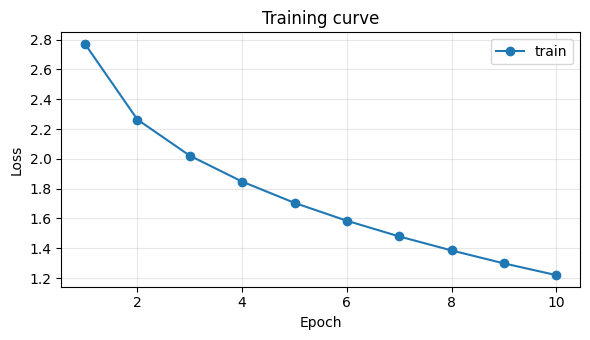

Generating:   0%|          | 0/643 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Ein Mangel an Vitamin D kann zu zahlreichen gesundheitlichen Problemen führen, darunter Osteoporose, Autoimmunerkrankungen und Depressionen. Unser Körper ist jedoch in der Lage, Vitamin D durch Sonneneinstrahlung selbst zu synthetisieren. Daher ist es wichtig, sich ausreichend lange im Freien aufzuhalten, um eine ausreichende Menge an Vitamin D zu erhalten.

Vitamin D ist ein essenzieller Nährstoff für unseren Körper und spielt eine entscheidende Rolle bei der Erhaltung von Knochen und Zahn gesundheit sowie in der Prävention von Autoimmunerkrankungen und Herz-Kreislauf-Erkrankungen. Es hilft dem Körper dabei, Calcium und Phosphat aufzunehmen, die für den Knochenaufbau notwendig sind. Darüber hinaus ist es ein wichtiger Regulator des Immunsystems und kann helfen, Entzündungen zu reduzieren.

Da Vitamin D unter Sonnenlicht synthetisiert wird, ist es besonders wichtig, sich regelmäßig im Freien aufzuhalten und dabei die richtige Balance z

In [ ]:
# -----------------------------------------------------------------------------
# 0. Make sure all required packages are available in the active kernel
# -----------------------------------------------------------------------------
REQUIRED = {  # module name -> pip name
    "torch": "torch",
    "transformers": "transformers",
    "sentencepiece": "sentencepiece",
    "sacrebleu": "sacrebleu",
    "rouge_score": "rouge-score",
    "tqdm": "tqdm",
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

# -----------------------------------------------------------------------------
# 1. Config, device & seeds
# -----------------------------------------------------------------------------
SEED = 42
MODEL_NAME = "google/flan-t5-base"
MAX_INPUT_LEN = 256
MAX_TARGET_LEN = 64
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
PREFIX = "formalisieren: "

# Checkpointing
WEIGHTS_DIR = "/content/drive/MyDrive/Dataset/german_text/weights"
RESUME = True        # automatically continue from the latest checkpoint if one exists
KEEP_LAST_N = 3      # keep only the N newest epoch checkpoints (~3 GB each); None = keep all

random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# -----------------------------------------------------------------------------
# 1b. Mount Google Drive and prepare the weights folder
# -----------------------------------------------------------------------------
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    print("Not running in Google Colab - checkpoints will be written to the local path below.")

os.makedirs(WEIGHTS_DIR, exist_ok=True)
print(f"Checkpoint folder: {WEIGHTS_DIR}")
print(f"Data split -> train: {len(train_data)} | test: {len(test_data)}")

# -----------------------------------------------------------------------------
# 3. Tokenizer & pretrained seq2seq model
# -----------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

# -----------------------------------------------------------------------------
# 4. Dataset
# -----------------------------------------------------------------------------
class TextToTextDataset(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer, max_input_len=64, max_target_len=64):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        input_enc = self.tokenizer(
            item["input"],
            max_length=self.max_input_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        target_enc = self.tokenizer(
            text_target=item["target"],
            max_length=self.max_target_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        labels = target_enc["input_ids"].squeeze(0).clone()
        labels[labels == self.tokenizer.pad_token_id] = -100  # ignore padding in the loss

        return {
            "input_ids": input_enc["input_ids"].squeeze(0),
            "attention_mask": input_enc["attention_mask"].squeeze(0),
            "labels": labels,
        }


def make_loader(data, shuffle):
    ds = TextToTextDataset(data, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
    return torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = make_loader(train_data, shuffle=True)
test_loader = make_loader(test_data, shuffle=False)

# -----------------------------------------------------------------------------
# 5. Optimizer
# -----------------------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# -----------------------------------------------------------------------------
# 5b. Checkpoint helpers (save after every epoch / resume after an interruption)
# -----------------------------------------------------------------------------
def _epoch_of(path):
    return int(re.search(r"checkpoint_epoch_(\d+)\.pt$", path).group(1))

def list_checkpoints():
    """All finished checkpoints, oldest -> newest (unfinished *.tmp files are ignored)."""
    files = glob.glob(os.path.join(WEIGHTS_DIR, "checkpoint_epoch_*.pt"))
    return sorted(files, key=_epoch_of)


def save_checkpoint(epoch, history):
    """Save model + optimizer + RNG state. Written to a temp file first and then renamed,
    so an interruption during saving can never leave a corrupt 'latest' checkpoint."""
    path = os.path.join(WEIGHTS_DIR, f"checkpoint_epoch_{epoch:02d}.pt")
    tmp_path = path + ".tmp"

    state = {
        "epoch": epoch,  # number of fully completed epochs
        "model_name": MODEL_NAME,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "python_rng_state": random.getstate(),
    }
    torch.save(state, tmp_path)
    os.replace(tmp_path, path)

    # Delete older checkpoints to save Drive space
    if KEEP_LAST_N is not None:
        for old in list_checkpoints()[:-KEEP_LAST_N]:
            os.remove(old)
    return path


def load_latest_checkpoint():
    """Restore the newest readable checkpoint. Returns (completed_epochs, history)."""
    for path in reversed(list_checkpoints()):
        try:
            ckpt = torch.load(path, map_location="cpu", weights_only=False)
        except Exception as e:  # e.g. file damaged by an interruption
            print(f"Could not read {os.path.basename(path)} ({e}); trying an older checkpoint ...")
            continue

        if ckpt.get("model_name") != MODEL_NAME:
            print(f"Warning: checkpoint was trained from '{ckpt.get('model_name')}', current model is '{MODEL_NAME}'.")

        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        torch.set_rng_state(ckpt["torch_rng_state"].cpu())
        if ckpt.get("cuda_rng_state_all") is not None and torch.cuda.is_available():
            try:
                torch.cuda.set_rng_state_all([s.cpu() for s in ckpt["cuda_rng_state_all"]])
            except Exception:
                pass
        random.setstate(ckpt["python_rng_state"])

        print(f"Resumed from {os.path.basename(path)} -> {ckpt['epoch']} epoch(s) already completed.")
        return ckpt["epoch"], ckpt["history"]

    return 0, {"train_loss": []}


start_epoch, history = 0, {"train_loss": []}
if RESUME and list_checkpoints():
    start_epoch, history = load_latest_checkpoint()
    model.to(device)
else:
    print("No checkpoint found (or RESUME=False) - starting from scratch.")

# -----------------------------------------------------------------------------
# 6. Training with live progress (no validation; the final model is used)
# -----------------------------------------------------------------------------
if start_epoch >= EPOCHS:
    print(f"Training already finished ({start_epoch}/{EPOCHS} epochs) - skipping to evaluation.")
else:
    print(f"\nStarting training at epoch {start_epoch + 1}/{EPOCHS}, {len(train_loader)} steps/epoch\n")
    train_start = time.time()

    for epoch in range(start_epoch + 1, EPOCHS + 1):
        model.train()
        epoch_start = time.time()
        running_loss, running_tokens = 0.0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=True)
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}

            loss = model(**batch).loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            n_tok = (batch["labels"] != -100).sum().item()
            running_loss += loss.item() * n_tok
            running_tokens += n_tok
            pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{running_loss / running_tokens:.4f}")

        train_loss = running_loss / running_tokens
        history["train_loss"].append(train_loss)

        # ---- save weights after every epoch ----
        ckpt_path = save_checkpoint(epoch, history)

        tqdm.write(
            f"Epoch {epoch:02d}/{EPOCHS} | train loss: {train_loss:.4f} | "
            f"{time.time() - epoch_start:.1f}s | saved -> {os.path.basename(ckpt_path)}"
        )

    print(f"\nTraining finished in {time.time() - train_start:.1f}s | "
          f"final train loss: {history['train_loss'][-1]:.4f}")

# Save the final model in Hugging Face format (reload later with from_pretrained)
FINAL_DIR = os.path.join(WEIGHTS_DIR, "final_model")
model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
print(f"Final model saved to: {FINAL_DIR}")
# Optional: loss curve
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3.5))
    plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o", label="train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

# -----------------------------------------------------------------------------
# 7. Evaluation on the held-out test set
# -----------------------------------------------------------------------------
@torch.no_grad()
def evaluate_loss(loader):
    """Token-weighted average loss over a loader (no gradient updates)."""
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model(**batch).loss
        n_tok = (batch["labels"] != -100).sum().item()
        total_loss += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def generate_predictions(data, batch_size=8):
    model.eval()
    preds = []
    for i in tqdm(range(0, len(data), batch_size), desc="Generating", leave=False):
        chunk = data[i:i + batch_size]
        enc = tokenizer(
            [x["input"] for x in chunk],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LEN,
        ).to(device)
        out = model.generate(
            **enc,
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True,
        )
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return preds


class UnicodeTokenizer:
    """ROUGE tokenizer that keeps German umlauts / ß (the default one strips them)."""

    def tokenize(self, text):
        return re.findall(r"\w+", text.lower())

def normalize(text):
    return re.sub(r"\s+", " ", text).strip()

def compute_metrics(predictions, references):
    # Exact match (case-sensitive)
    exact = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references)) / len(references)

    # BLEU & chrF (corpus level; chrF is character-based and robust for German morphology)
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    chrf = sacrebleu.corpus_chrf(predictions, [references])

    # ROUGE-1 / 2 / L (F1, averaged over examples)
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], tokenizer=UnicodeTokenizer())
    rouge = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for p, r in zip(predictions, references):
        scores = scorer.score(r, p)
        for k in rouge:
            rouge[k] += scores[k].fmeasure
    rouge = {k: v / len(references) for k, v in rouge.items()}

    # Length ratio (prediction words / reference words); ~1.0 is ideal
    len_ratio = sum(len(p.split()) for p in predictions) / max(sum(len(r.split()) for r in references), 1)

    return {
        "exact_match": exact * 100,
        "bleu": bleu.score,
        "chrf": chrf.score,
        "rouge1": rouge["rouge1"] * 100,
        "rouge2": rouge["rouge2"] * 100,
        "rougeL": rouge["rougeL"] * 100,
        "length_ratio": len_ratio,
    }


test_inputs = [x["input"] for x in test_data]
test_refs = [x["target"] for x in test_data]
test_preds = generate_predictions(test_data)

test_loss = evaluate_loss(test_loader)
metrics = compute_metrics(test_preds, test_refs)

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)
print(f"Examples        : {len(test_data)}")
print(f"Test loss       : {test_loss:.4f}")
print(f"Test perplexity : {float(torch.exp(torch.tensor(test_loss))):.2f}")
print(f"Exact match     : {metrics['exact_match']:.1f} %")
print(f"BLEU            : {metrics['bleu']:.2f}")
print(f"chrF            : {metrics['chrf']:.2f}")
print(f"ROUGE-1 (F1)    : {metrics['rouge1']:.2f}")
print(f"ROUGE-2 (F1)    : {metrics['rouge2']:.2f}")
print(f"ROUGE-L (F1)    : {metrics['rougeL']:.2f}")
print(f"Length ratio    : {metrics['length_ratio']:.2f}")

print("\n" + "-" * 70)
print("PER-EXAMPLE RESULTS")
print("-" * 70)
for inp, ref, pred in zip(test_inputs, test_refs, test_preds):
    ok = "OK " if normalize(pred) == normalize(ref) else "DIF"
    print(f"[{ok}] Input     : {inp}")
    print(f"      Reference : {ref}")
    print(f"      Prediction: {pred}\n")

# -----------------------------------------------------------------------------
# 8. Single-sentence inference
# -----------------------------------------------------------------------------
test_input = PREFIX + "Sag mir Bescheid, wenn du Zeit hast."
enc = tokenizer(test_input, return_tensors="pt").to(device)
model.eval()
with torch.no_grad():
    generated_ids = model.generate(**enc, max_length=MAX_TARGET_LEN, num_beams=4, early_stopping=True)
print(f"Input:  '{test_input}'")
print(f"Output: '{tokenizer.decode(generated_ids[0], skip_special_tokens=True)}'")

In [ ]:

# -----------------------------------------------------------------------------
# 0. Make sure all required packages are available in the active kernel
# -----------------------------------------------------------------------------
REQUIRED = {  # module name -> pip name
    "torch": "torch",
    "transformers": "transformers",
    "sentencepiece": "sentencepiece",
    "sacrebleu": "sacrebleu",
    "rouge_score": "rouge-score",
    "tqdm": "tqdm",
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import torch
import sacrebleu
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# -----------------------------------------------------------------------------
# 1. Config, device & seeds
# -----------------------------------------------------------------------------
SEED = 42
MODEL_NAME = "google/flan-t5-base"
MAX_INPUT_LEN = 64
MAX_TARGET_LEN = 64
BATCH_SIZE = 2
EPOCHS = 10
LR = 5e-5
PREFIX = "formalisieren: "

random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print(f"Data split -> train: {len(train_data)} | test: {len(test_data)}")

# -----------------------------------------------------------------------------
# 3. Tokenizer & pretrained seq2seq model
# -----------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)


# -----------------------------------------------------------------------------
# 4. Dataset
# -----------------------------------------------------------------------------
class TextToTextDataset(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer, max_input_len=64, max_target_len=64):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        input_enc = self.tokenizer(
            item["input"],
            max_length=self.max_input_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        target_enc = self.tokenizer(
            text_target=item["target"],
            max_length=self.max_target_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        labels = target_enc["input_ids"].squeeze(0).clone()
        labels[labels == self.tokenizer.pad_token_id] = -100  # ignore padding in the loss

        return {
            "input_ids": input_enc["input_ids"].squeeze(0),
            "attention_mask": input_enc["attention_mask"].squeeze(0),
            "labels": labels,
        }


def make_loader(data, shuffle):
    ds = TextToTextDataset(data, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
    return torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = make_loader(train_data, shuffle=True)
test_loader = make_loader(test_data, shuffle=False)

# -----------------------------------------------------------------------------
# 5. Optimizer
# -----------------------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# -----------------------------------------------------------------------------
# 6. Training with live progress (no validation; the final model is used)
# -----------------------------------------------------------------------------
history = {"train_loss": []}

print(f"\nStarting training: {EPOCHS} epochs, {len(train_loader)} steps/epoch\n")
train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_start = time.time()
    running_loss, running_tokens = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=True)
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}

        loss = model(**batch).loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        n_tok = (batch["labels"] != -100).sum().item()
        running_loss += loss.item() * n_tok
        running_tokens += n_tok
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{running_loss / running_tokens:.4f}")

    train_loss = running_loss / running_tokens
    history["train_loss"].append(train_loss)

    tqdm.write(
        f"Epoch {epoch:02d}/{EPOCHS} | train loss: {train_loss:.4f} | "
        f"{time.time() - epoch_start:.1f}s"
    )

print(f"\nTraining finished in {time.time() - train_start:.1f}s | final train loss: {history['train_loss'][-1]:.4f}")

# Optional: loss curve
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3.5))
    plt.plot(range(1, EPOCHS + 1), history["train_loss"], marker="o", label="train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    pass


# -----------------------------------------------------------------------------
# 7. Evaluation on the held-out test set
# -----------------------------------------------------------------------------
@torch.no_grad()
def evaluate_loss(loader):
    """Token-weighted average loss over a loader (no gradient updates)."""
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model(**batch).loss
        n_tok = (batch["labels"] != -100).sum().item()
        total_loss += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def generate_predictions(data, batch_size=8):
    model.eval()
    preds = []
    for i in tqdm(range(0, len(data), batch_size), desc="Generating", leave=False):
        chunk = data[i:i + batch_size]
        enc = tokenizer(
            [x["input"] for x in chunk],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LEN,
        ).to(device)
        out = model.generate(
            **enc,
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True,
        )
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return preds


class UnicodeTokenizer:
    """ROUGE tokenizer that keeps German umlauts / ß (the default one strips them)."""

    def tokenize(self, text):
        return re.findall(r"\w+", text.lower())


def normalize(text):
    return re.sub(r"\s+", " ", text).strip()


def compute_metrics(predictions, references):
    # Exact match (case-sensitive)
    exact = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references)) / len(references)

    # BLEU & chrF (corpus level; chrF is character-based and robust for German morphology)
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    chrf = sacrebleu.corpus_chrf(predictions, [references])

    # ROUGE-1 / 2 / L (F1, averaged over examples)
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], tokenizer=UnicodeTokenizer())
    rouge = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for p, r in zip(predictions, references):
        scores = scorer.score(r, p)
        for k in rouge:
            rouge[k] += scores[k].fmeasure
    rouge = {k: v / len(references) for k, v in rouge.items()}

    # Length ratio (prediction words / reference words); ~1.0 is ideal
    len_ratio = sum(len(p.split()) for p in predictions) / max(sum(len(r.split()) for r in references), 1)

    return {
        "exact_match": exact * 100,
        "bleu": bleu.score,
        "chrf": chrf.score,
        "rouge1": rouge["rouge1"] * 100,
        "rouge2": rouge["rouge2"] * 100,
        "rougeL": rouge["rougeL"] * 100,
        "length_ratio": len_ratio,
    }


test_inputs = [x["input"] for x in test_data]
test_refs = [x["target"] for x in test_data]
test_preds = generate_predictions(test_data)

test_loss = evaluate_loss(test_loader)
metrics = compute_metrics(test_preds, test_refs)

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)
print(f"Examples        : {len(test_data)}")
print(f"Test loss       : {test_loss:.4f}")
print(f"Test perplexity : {float(torch.exp(torch.tensor(test_loss))):.2f}")
print(f"Exact match     : {metrics['exact_match']:.1f} %")
print(f"BLEU            : {metrics['bleu']:.2f}")
print(f"chrF            : {metrics['chrf']:.2f}")
print(f"ROUGE-1 (F1)    : {metrics['rouge1']:.2f}")
print(f"ROUGE-2 (F1)    : {metrics['rouge2']:.2f}")
print(f"ROUGE-L (F1)    : {metrics['rougeL']:.2f}")
print(f"Length ratio    : {metrics['length_ratio']:.2f}")

print("\n" + "-" * 70)
print("PER-EXAMPLE RESULTS")
print("-" * 70)
for inp, ref, pred in zip(test_inputs, test_refs, test_preds):
    ok = "OK " if normalize(pred) == normalize(ref) else "DIF"
    print(f"[{ok}] Input     : {inp}")
    print(f"      Reference : {ref}")
    print(f"      Prediction: {pred}\n")

# -----------------------------------------------------------------------------
# 8. Single-sentence inference
# -----------------------------------------------------------------------------
test_input = PREFIX + "Sag mir Bescheid, wenn du Zeit hast."
enc = tokenizer(test_input, return_tensors="pt").to(device)
model.eval()
with torch.no_grad():
    generated_ids = model.generate(**enc, max_length=MAX_TARGET_LEN, num_beams=4, early_stopping=True)
print(f"Input:  '{test_input}'")
print(f"Output: '{tokenizer.decode(generated_ids[0], skip_special_tokens=True)}'")

In [ ]:

# Now, let's read the content of the 'sample.txt' file
test1_in_path = "/content/drive/MyDrive/Dataset/german_text/test_txt/text1.txt"
text1_out_path = "/content/drive/MyDrive/Dataset/german_text/test_txt/output1.txt"
try:
    with open(test1_in_path, "r") as file:
        content = file.read()
        print(f"Content of '{test1_in_path}':\n{content}")
except FileNotFoundError:
    print(f"Error: The file '{test1_in_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")



Content of '/content/drive/MyDrive/Dataset/german_text/test_txt/text1.txt':
Am neuen Bahnhaltepunkt Pallien beginnen in der kommenden Woche umfangreiche Bauarbeiten zur Gestaltung des Umfelds und zur Verkehrserschließung. Im ersten Bauabschnitt bis voraussichtlich März 2027 konzentrieren sich die Arbeiten auf die Bonner Straße. Die Baustelle wird ab Montag, 28. September, eingerichtet. Bis Donnerstag, 1. Oktober, gibt es dabei noch keine Einschränkungen für den Durchgangs- und Anliegerverkehr. Das teilt die Stadt Trier mit. Die Vollsperrung zwischen den Einmündungen der Kölner Straße und der Palliener Straße beginnt anders als zunächst angekündigt erst am Freitag, 2. Oktober.

Umleitungen für den Verkehr
Während der Sperrung wird der Verkehr großräumig umgeleitet. Aus Richtung Trier-West führt die Umleitung über die Bitburger Straße, die Autobahn A 64 und die B 53 bis zur Baustelle. Aus Richtung Innenstadt verläuft sie über die A 602, die Moselbrücke Ehrang und die B 53.

Da es im weit

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import os

# Define the directory where the model was saved
FINAL_DIR = os.path.join("/content/drive/MyDrive/Dataset/german_text/weights", "final_model")
MAX_TARGET_LEN = 64
# Check if the directory exists
if os.path.exists(FINAL_DIR):
    # Load the tokenizer and model
    loaded_tokenizer = AutoTokenizer.from_pretrained(FINAL_DIR)
    loaded_model = AutoModelForSeq2SeqLM.from_pretrained(FINAL_DIR)
    print("Model and tokenizer loaded successfully from: ", FINAL_DIR)
else:
    print(f"Error: Model directory not found at {FINAL_DIR}")

# Now you can use loaded_tokenizer and loaded_model for inference
# For example, to make a single-sentence inference with the loaded model:

# Define a test input (use the same PREFIX as during training)
PREFIX = "formalisieren: " + content
test_input_loaded = PREFIX + "Ich bin froh, dich zu sehen."

# Encode the input using the loaded tokenizer
enc_loaded = loaded_tokenizer(test_input_loaded, return_tensors="pt")

# Generate the output using the loaded model
loaded_model.eval()
with torch.no_grad():
    generated_ids_loaded = loaded_model.generate(**enc_loaded, max_length=MAX_TARGET_LEN, num_beams=4, early_stopping=True)

# Decode and print the output
print(f"\nInput (loaded model):  '{test_input_loaded}'")
print(f"Output (loaded model): '{loaded_tokenizer.decode(generated_ids_loaded[0], skip_special_tokens=True)}'")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model and tokenizer loaded successfully from:  /content/drive/MyDrive/Dataset/german_text/weights/final_model

Input (loaded model):  'formalisieren: Am neuen Bahnhaltepunkt Pallien beginnen in der kommenden Woche umfangreiche Bauarbeiten zur Gestaltung des Umfelds und zur Verkehrserschließung. Im ersten Bauabschnitt bis voraussichtlich März 2027 konzentrieren sich die Arbeiten auf die Bonner Straße. Die Baustelle wird ab Montag, 28. September, eingerichtet. Bis Donnerstag, 1. Oktober, gibt es dabei noch keine Einschränkungen für den Durchgangs- und Anliegerverkehr. Das teilt die Stadt Trier mit. Die Vollsperrung zwischen den Einmündungen der Kölner Straße und der Palliener Straße beginnt anders als zunächst angekündigt erst am Freitag, 2. Oktober.

Umleitungen für den Verkehr
Während der Sperrung wird der Verkehr großräumig umgeleitet. Aus Richtung Trier-West führt die Umleitung über die Bitburger Straße, die Autobahn A 64 und die B 53 bis zur Baustelle. Aus Richtung Innenstadt verläu

In [ ]:
import torch
from tqdm.auto import tqdm
import re
import sacrebleu
from rouge_score import rouge_scorer

# Ensure device is defined, as it's used in loaded_model.to(device) in cell 82491f6a
device = torch.device("cuda" if torch.cuda.is_avail able() else "cpu")

# Re-define TextToTextDataset and make_loader to use loaded_tokenizer and MAX_TARGET_LEN
# MAX_INPUT_LEN should also be available from nCM3Yo1ldrEF
# Assuming MAX_INPUT_LEN is in global scope from nCM3Yo1ldrEF (it was 64)
# Assuming MAX_TARGET_LEN is in global scope from 82491f6a (it was 64)
MAX_INPUT_LEN = 64
BATCH_SIZE = 2
class TextToTextDatasetLoaded(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer, max_input_len, max_target_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        input_enc = self.tokenizer(
            item["input"],
            max_length=self.max_input_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        target_enc = self.tokenizer(
            text_target=item["target"],
            max_length=self.max_target_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        labels = target_enc["input_ids"].squeeze(0).clone()
        labels[labels == self.tokenizer.pad_token_id] = -100  # ignore padding in the loss

        return {
            "input_ids": input_enc["input_ids"].squeeze(0),
            "attention_mask": input_enc["attention_mask"].squeeze(0),
            "labels": labels,
        }

def make_loader_loaded(data, shuffle, tokenizer_obj, max_input_len, max_target_len, batch_size):
    ds = TextToTextDatasetLoaded(data, tokenizer_obj, max_input_len, max_target_len)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


# Redefine evaluate_loss to use the loaded_model
@torch.no_grad()
def evaluate_loss_loaded(loader, model_obj, device):
    model_obj.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model_obj(**batch).loss
        n_tok = (batch["labels"] != -100).sum().item()
        total_loss += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)

# Redefine generate_predictions to use the loaded_model and loaded_tokenizer
@torch.no_grad()
def generate_predictions_loaded(data, model_obj, tokenizer_obj, device, batch_size=8, max_input_len=MAX_INPUT_LEN, max_target_len=MAX_TARGET_LEN):
    model_obj.eval()
    preds = []
    for i in tqdm(range(0, len(data), batch_size), desc="Generating (Loaded Model)", leave=False):
        chunk = data[i:i + batch_size]
        enc = tokenizer_obj(
            [x["input"] for x in chunk],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_input_len,
        ).to(device)
        out = model_obj.generate(
            **enc,
            max_length=max_target_len,
            num_beams=4,
            early_stopping=True,
        )
        preds.extend(tokenizer_obj.batch_decode(out, skip_special_tokens=True))
    return preds

class UnicodeTokenizer:
    """ROUGE tokenizer that keeps German umlauts / ß (the default one strips them)."""

    def tokenize(self, text):
        return re.findall(r"\w+", text.lower())

def normalize(text):
    return re.sub(r"\s+", " ", text).strip()

def compute_metrics(predictions, references):
    # Exact match (case-sensitive)
    exact = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references)) / len(references)

    # BLEU & chrF (corpus level; chrF is character-based and robust for German morphology)
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    chrf = sacrebleu.corpus_chrf(predictions, [references])

    # ROUGE-1 / 2 / L (F1, averaged over examples)
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], tokenizer=UnicodeTokenizer())
    rouge = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for p, r in zip(predictions, references):
        scores = scorer.score(r, p)
        for k in rouge:
            rouge[k] += scores[k].fmeasure
    rouge = {k: v / len(references) for k, v in rouge.items()}

    # Length ratio (prediction words / reference words); ~1.0 is ideal
    len_ratio = sum(len(p.split()) for p in predictions) / max(sum(len(r.split()) for r in references), 1)

    return {
        "exact_match": exact * 100,
        "bleu": bleu.score,
        "chrf": chrf.score,
        "rouge1": rouge["rouge1"] * 100,
        "rouge2": rouge["rouge2"] * 100,
        "rougeL": rouge["rougeL"] * 100,
        "length_ratio": len_ratio,
    }


# Create a test_loader for the loaded model with the loaded_tokenizer
test_loader_loaded = make_loader_loaded(test_data, shuffle=False, tokenizer_obj=loaded_tokenizer, max_input_len=MAX_INPUT_LEN, max_target_len=MAX_TARGET_LEN, batch_size=BATCH_SIZE)

# Generate predictions using the loaded model
test_inputs_loaded = [x["input"] for x in test_data]
test_refs = [x["target"] for x in test_data]
test_preds_loaded = generate_predictions_loaded(test_data, loaded_model, loaded_tokenizer, device)

# Evaluate loss using the loaded model
test_loss_loaded = evaluate_loss_loaded(test_loader_loaded, loaded_model, device)
metrics_loaded = compute_metrics(test_preds_loaded, test_refs)

print("\n" + "=" * 70)
print("LOADED MODEL TEST SET EVALUATION")
print("=" * 70)
print(f"Examples        : {len(test_data)}")
print(f"Test loss       : {test_loss_loaded:.4f}")
print(f"Test perplexity : {float(torch.exp(torch.tensor(test_loss_loaded))):.2f}")
print(f"Exact match     : {metrics_loaded['exact_match']:.1f} %")
print(f"BLEU            : {metrics_loaded['bleu']:.2f}")
print(f"chrF            : {metrics_loaded['chrf']:.2f}")
print(f"ROUGE-1 (F1)    : {metrics_loaded['rouge1']:.2f}")
print(f"ROUGE-2 (F1)    : {metrics_loaded['rouge2']:.2f}")
print(f"ROUGE-L (F1)    : {metrics_loaded['rougeL']:.2f}")
print(f"Length ratio    : {metrics_loaded['length_ratio']:.2f}")

print("\n" + "-" * 70)
print("PER-EXAMPLE RESULTS (Loaded Model)")
print("-" * 70)
for inp, ref, pred in zip(test_inputs_loaded, test_refs, test_preds_loaded):
    ok = "OK " if normalize(pred) == normalize(ref) else "DIF"
    print(f"[{ok}] Input     : {inp}")
    print(f"      Reference : {ref}")
    print(f"      Prediction: {pred}\n")

Generating (Loaded Model):   0%|          | 0/643 [00:00<?, ?it/s]


LOADED MODEL TEST SET EVALUATION
Examples        : 5140
Test loss       : 2.3273
Test perplexity : 10.25
Exact match     : 0.1 %
BLEU            : 4.11
chrF            : 28.59
ROUGE-1 (F1)    : 19.89
ROUGE-2 (F1)    : 5.55
ROUGE-L (F1)    : 17.53
Length ratio    : 0.90

----------------------------------------------------------------------
PER-EXAMPLE RESULTS (Loaded Model)
----------------------------------------------------------------------
[DIF] Input     : formalisieren: Luftverschmutzung ist ein globales Umweltproblem, das immer dringlicher wird. Die Belastung durch Feinstaub und Stickstoffoxide hat in vielen europäischen Städten bereits dramatische Ausmaße angenommen. Die schlechte Luftqualität führt nicht nur zu einem deutlichen Anstieg von Atemwegserkrankungen und Lungenerkrankungen, sondern beeinträchtigt auch die Lebensqualität in den betroffenen Regionen erheblich.

Ein besonders besorgniserregendes Beispiel ist das deutsche Rhein-Main-Gebiet, das unter einer hohen Luftver